# GeoWatch Copilot — SegFormer Fine-tuning (Path B)

**Purpose:** Replace Path A tile-level CLIP classification with per-segment semantic segmentation using SegFormer.

**Encoder:** SegFormer-B2 with ImageNet-1k pretrained weights (frozen). Clay v1 was evaluated and
found architecturally incompatible — see the note in the model section below. This is a documented,
investigated decision, not a silent fallback.

**Training data:** 5 cities x SAM annotations + OSM-derived paved-road masks + sliding-window patches


## 0. Install dependencies

In [ ]:
!pip install -q transformers timm einops geopandas shapely scipy pillow matplotlib seaborn scikit-learn
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q huggingface_hub

print('Dependencies installed.')


Dependencies installed.


## 1. Load data from Drive

One cell. Mounts Drive, copies annotations/tiles/result.json and the OSM roads/waterways
geojson (from each run's `osm/` subfolder) into `/content/data/{city}/`, then auto-discovers
which cities are actually usable and pulls their AOI bounding boxes from `result.json`.

Update `CITY_MAP` below if your run IDs change.


In [28]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, shutil, json

DRIVE_BASE = '/content/drive/MyDrive/Geowatch'
DATA_ROOT = '/content/data'

CITY_MAP = {
    # Annotated with fixed pipeline (real mask_rle) — 6 done
    'dharavi': 'dharavi_20260702_163012',
    'nairobi': 'nairobi_20260702_164731',
    'jakarta': 'jakarta_20260702_163609',
    'hcmc':    'hcmc_20260702_163714',
    'kigali':  'kigali_20260702_163814',
    'accra':   'accra_20260702_163854',
}

os.makedirs(DATA_ROOT, exist_ok=True)

# tile_0_0.png location differs between pipeline versions:
#   - original 5 cities: run_dir/tile_0_0.png
#   - new 6 cities:       run_dir/tiles/tile_0_0.png
TILE_SUBPATHS = ['tile_0_0.png', 'tiles/tile_0_0.png']

MAIN_FILES_NO_TILE = ['annotations.json', 'result.json']
OSM_FILES = ['roads.geojson', 'waterways.geojson']

for city, run_id in CITY_MAP.items():
    run_dir = f'{DRIVE_BASE}/{run_id}'
    dst_dir = f'{DATA_ROOT}/{city}'
    os.makedirs(dst_dir, exist_ok=True)

    if not os.path.isdir(run_dir):
        print(f'X {city}: run dir not found at {run_dir} -- skipping')
        continue

    copied, missing = [], []

    for f in MAIN_FILES_NO_TILE:
        src_path = f'{run_dir}/{f}'
        if os.path.isfile(src_path):
            shutil.copy(src_path, f'{dst_dir}/{f}')
            copied.append(f)
        else:
            missing.append(f)

    tile_found = False
    for sub in TILE_SUBPATHS:
        src_path = f'{run_dir}/{sub}'
        if os.path.isfile(src_path):
            shutil.copy(src_path, f'{dst_dir}/tile_0_0.png')
            copied.append(f'tile_0_0.png (from {sub})')
            tile_found = True
            break
    if not tile_found:
        missing.append('tile_0_0.png (checked: ' + ', '.join(TILE_SUBPATHS) + ')')

    osm_dir = f'{run_dir}/osm'
    for f in OSM_FILES:
        src_path = f'{osm_dir}/{f}'
        if os.path.isfile(src_path):
            shutil.copy(src_path, f'{dst_dir}/{f}')
            copied.append(f'osm/{f}')
        else:
            missing.append(f'osm/{f}')

    status = 'OK' if not missing else f'partial (missing: {missing})'
    print(f'{city:<10} <- {run_id:<26} [{status}]  copied: {copied}')

print('\nData load complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dharavi    <- dharavi_20260702_163012    [OK]  copied: ['annotations.json', 'result.json', 'tile_0_0.png (from tiles/tile_0_0.png)', 'osm/roads.geojson', 'osm/waterways.geojson']
nairobi    <- nairobi_20260702_164731    [OK]  copied: ['annotations.json', 'result.json', 'tile_0_0.png (from tiles/tile_0_0.png)', 'osm/roads.geojson', 'osm/waterways.geojson']
jakarta    <- jakarta_20260702_163609    [OK]  copied: ['annotations.json', 'result.json', 'tile_0_0.png (from tiles/tile_0_0.png)', 'osm/roads.geojson', 'osm/waterways.geojson']
hcmc       <- hcmc_20260702_163714       [OK]  copied: ['annotations.json', 'result.json', 'tile_0_0.png (from tiles/tile_0_0.png)', 'osm/roads.geojson', 'osm/waterways.geojson']
kigali     <- kigali_20260702_163814     [OK]  copied: ['annotations.json', 'result.json', 'tile_0_0.png (from tiles/tile_0_0.png)', 'osm/roads.geojson', '

## 1b. Verify and auto-discover

In [30]:
import os, json

DATA_ROOT = '/content/data'

# RESTRICTED to the 6 cities verified to have real mask_rle annotations
# (confirmed via the label-canvas check: "N real masks, 0 bbox fallback").
# Do NOT auto-discover via os.listdir here -- dhaka/lagos/capetown/
# guatemala/nusantara still point to their OLD pre-fix run folders,
# which already contain an annotations.json (just without mask_rle).
# Auto-discovery based on "does annotations.json exist" can't tell clean
# from dirty data apart -- it would silently pull in all 11 and
# contaminate the LOCO result with bbox-fallback cities again.
LOCO_CLEAN_CITIES = [
    'dharavi',
    'accra',
    'nairobi',
    'jakarta',
    'hcmc',
    'kigali',
]

CITIES = [
    city for city in LOCO_CLEAN_CITIES
    if os.path.isfile(f'{DATA_ROOT}/{city}/annotations.json')
    and os.path.isfile(f'{DATA_ROOT}/{city}/tile_0_0.png')
]

missing = set(LOCO_CLEAN_CITIES) - set(CITIES)
if missing:
    print(f"⚠ WARNING: expected 6 clean cities but these are missing files: {missing}")
    print(f"  Check CITY_MAP in cell 4 points to the new run_ids and Drive sync ran.")

print(f"Found {len(CITIES)}/6 clean cities for LOCO: {CITIES}")

# Pull bboxes from result.json instead of hardcoding
CITY_BBOXES = {}
for city in CITIES:
    result_path = f'{DATA_ROOT}/{city}/result.json'
    if os.path.isfile(result_path):
        with open(result_path) as f:
            aoi = json.load(f)['aoi']
        CITY_BBOXES[city] = [aoi['west'], aoi['south'], aoi['east'], aoi['north']]
        print(f"  ✓ {city}: bbox loaded")
    else:
        print(f"  ⚠ {city}: no result.json — OSM patches will be skipped")

print(f"\nReady. {len(CITY_BBOXES)} cities with bboxes.")

if len(CITIES) < 6:
    print("\n⚠ Stopping point: fix the missing cities above before proceeding to LOCO --")
    print("  a fold count below 6 changes what the LOCO loop below expects.")

Found 6/6 clean cities for LOCO: ['dharavi', 'accra', 'nairobi', 'jakarta', 'hcmc', 'kigali']
  ✓ dharavi: bbox loaded
  ✓ accra: bbox loaded
  ✓ nairobi: bbox loaded
  ✓ jakarta: bbox loaded
  ✓ hcmc: bbox loaded
  ✓ kigali: bbox loaded

Ready. 6 cities with bboxes.


## 2. Category definitions

In [31]:
# 7 ML-resolvable land-cover categories.
# unpaved_dirt_road, open_drainage_channel, open_waste are INTENTIONALLY
# excluded -- per project decision, these are physically unresolvable at
# Sentinel-2 10m resolution and are handled via OSM vector proximity
# labeling in the pipeline (osm_dem.py), not ML classification.
# Do not add them back into SegFormer training.
CATEGORIES = [
    'dense_informal_roofing',   # 0
    'sparse_informal_roofing',  # 1
    'paved_road',                # 2
    'standing_water',            # 3
    'vegetation_clearing',       # 4
    'active_construction',       # 5
    'dense_vegetation',          # 6
]
CAT2IDX = {c: i for i, c in enumerate(CATEGORIES)}
NUM_CLASSES = len(CATEGORIES)

# Label index 255 = ignore (unknown / unannotated pixels)
IGNORE_INDEX = 255

# NOTE: class weights are computed later (section 4) from the ACTUAL built
# patch dataset, not from annotation counts alone -- OSM-rasterized patches
# add hundreds of paved_road samples that annotation-only counts don't see.
# Computing weights before the dataset exists caused a real bug earlier
# (paved_road was both 77% of the data AND given the highest loss weight,
# which made the model collapse to predicting it everywhere). Do not
# reintroduce a pre-dataset CLASS_WEIGHTS computation here.

print(f'{NUM_CLASSES} categories defined: {CATEGORIES}')


7 categories defined: ['dense_informal_roofing', 'sparse_informal_roofing', 'paved_road', 'standing_water', 'vegetation_clearing', 'active_construction', 'dense_vegetation']


## 3. Dataset construction — three sources

- **SAM**: human-annotated segment crops
- **OSM**: paved roads only, rasterized from OSM geometry (unpaved_dirt_road /
  open_drainage_channel / open_waste are excluded -- OSM vector proximity handles those
  in the production pipeline instead)
- **Sliding window**: dense crops labeled by nearest annotated segment centroid


In [32]:
import json
import numpy as np
from PIL import Image
from pathlib import Path
import geopandas as gpd
from shapely.geometry import MultiLineString, LineString
import random

random.seed(42)
np.random.seed(42)

def decode_mask_rle(rle: dict) -> np.ndarray:
    """Matches ingestion/segmentation.py's encoder -- keep in sync."""
    h, w = rle["size"]
    counts = rle["counts"]
    flat = np.zeros(h * w, dtype=bool)
    idx = 0
    val = False
    for c in counts:
        if val:
            flat[idx:idx + c] = True
        idx += c
        val = not val
    return flat.reshape(w, h).T


def build_sam_patches(city: str, patch_size: int = 64) -> list:
    """
    CHANGED: uses the real SAM mask (mask_rle) to paint only the
    segment's actual shape as its label; everything else in the crop
    is IGNORE_INDEX, same philosophy as the OSM road patches. Falls
    back to the old full-bbox behavior only if mask_rle is missing
    (older annotations.json without the mask fix applied).
    """
    ann_path = Path(f'/content/data/{city}/annotations.json')
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')

    if not ann_path.exists() or not tile_path.exists():
        print(f'  [{city}] missing annotations.json or tile, skipping.')
        return []

    with open(ann_path) as f:
        ann_data = json.load(f)

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size

    patches_out = []
    skipped, unknown, excluded, no_mask = 0, 0, 0, 0

    for ann in ann_data['annotations']:
        if ann.get('skipped', False) or ann.get('human_label') is None:
            skipped += 1
            continue
        if ann['human_label'] == 'unknown':
            unknown += 1
            continue
        if ann['human_label'] not in CAT2IDX:
            excluded += 1
            continue

        x, y, w, h = ann['bbox']
        x1, y1 = max(0, x), max(0, y)
        x2, y2 = min(tile_w, x + w), min(tile_h, y + h)
        if x2 <= x1 or y2 <= y1:
            continue

        crop = tile_img.crop((x1, y1, x2, y2)).resize((patch_size, patch_size), Image.BILINEAR)
        crop_arr = np.array(crop, dtype=np.uint8)
        label_idx = CAT2IDX[ann['human_label']]

        mask_rle = ann.get('mask_rle')
        if mask_rle is not None:
            full_mask = decode_mask_rle(mask_rle)          # full tile-resolution boolean mask
            local_mask = full_mask[y1:y2, x1:x2]            # crop to this segment's bbox
            local_mask_img = Image.fromarray(local_mask.astype(np.uint8) * 255)
            local_mask_resized = local_mask_img.resize((patch_size, patch_size), Image.NEAREST)
            local_mask_arr = np.array(local_mask_resized) > 127

            label_mask = np.full((patch_size, patch_size), IGNORE_INDEX, dtype=np.uint8)
            label_mask[local_mask_arr] = label_idx
        else:
            no_mask += 1
            label_mask = np.full((patch_size, patch_size), label_idx, dtype=np.uint8)

        patches_out.append({
            'image': crop_arr,
            'mask': label_mask,
            'city': city,
            'source': 'sam',
            'label': ann['human_label'],
        })

    print(f'  [{city}] SAM patches: {len(patches_out)} usable | {skipped} skipped | '
          f'{unknown} unknown excluded | {excluded} OSM-only-category excluded | '
          f'{no_mask} used bbox fallback (no mask_rle)')
    return patches_out


def build_osm_patches(city: str, patch_size: int = 64, road_buffer_px: int = 2) -> list:
    """
    Source 2: OSM-derived training masks -- PAVED ROADS ONLY.

    FIX (visual inspection confirmed the actual problem): the original version
    labeled the ENTIRE 64x64 crop as paved_road, even though a road at 10m is
    a thin linear feature -- most of each crop is actually buildings/vegetation/
    open ground with the road just cutting through. That taught the model
    "generic mixed urban texture = paved_road" instead of "this specific
    pixel is road," which likely inflated paved_road's apparent F1 without
    it having learned anything precise.

    This version now labels ONLY pixels within `road_buffer_px` of the traced
    road line as paved_road. Everything else in the crop is set to
    IGNORE_INDEX (excluded from loss) rather than guessed at -- we don't
    know what those other pixels are just because they're near a road.

    unpaved_dirt_road and open_drainage_channel rasterization remains REMOVED
    -- those categories are handled via OSM vector proximity in the
    production pipeline (osm_dem.py), not SegFormer classification.
    """
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')
    roads_path = Path(f'/content/data/{city}/roads.geojson')

    if not tile_path.exists():
        return []

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size
    tile_arr = np.array(tile_img, dtype=np.uint8)

    west, south, east, north = CITY_BBOXES[city]
    lon_per_px = (east - west) / tile_w
    lat_per_px = (north - south) / tile_h

    aoi_km2 = (east - west) * 111 * (north - south) * 111
    sample_stride = max(20, int(aoi_km2 * 2))
    print(f'  [{city}] AOI ~{aoi_km2:.1f} km^2 -> road_stride={sample_stride}')

    def lon_to_px(lon):
        return (lon - west) / lon_per_px

    def lat_to_py(lat):
        return (north - lat) / lat_per_px

    PAVED_TYPES = {'primary', 'secondary', 'tertiary', 'trunk', 'motorway',
                   'primary_link', 'secondary_link', 'tertiary_link'}

    patches_out = []
    half = patch_size // 2

    def rasterize_lines(gdf, label_idx, label_name, stride):
        road_pixels = []
        all_road_pixels_global = []
        for _, row in gdf.iterrows():
            geom = row.geometry
            if geom is None:
                continue
            if isinstance(geom, MultiLineString):
                line_list = list(geom.geoms)
            elif isinstance(geom, LineString):
                line_list = [geom]
            else:
                continue

            for line in line_list:
                try:
                    coords = list(line.coords)
                except Exception:
                    continue
                for i in range(len(coords) - 1):
                    x0 = lon_to_px(coords[i][0])
                    y0 = lat_to_py(coords[i][1])
                    x1 = lon_to_px(coords[i+1][0])
                    y1 = lat_to_py(coords[i+1][1])
                    n = max(int(np.hypot(x1-x0, y1-y0)) * 2, 2)
                    xs = np.linspace(x0, x1, n)
                    ys = np.linspace(y0, y1, n)
                    for x, y in zip(xs, ys):
                        xi, yi = int(round(x)), int(round(y))
                        all_road_pixels_global.append((xi, yi))
                        if half <= xi < tile_w - half and half <= yi < tile_h - half:
                            road_pixels.append((xi, yi))

        if not road_pixels:
            return []

        road_pixel_set = set(all_road_pixels_global)

        sampled = road_pixels[::stride]
        result = []
        for cx, cy in sampled:
            crop_arr = tile_arr[cy-half:cy+half, cx-half:cx+half]
            if crop_arr.shape[:2] != (patch_size, patch_size):
                continue

            label_mask = np.full((patch_size, patch_size), IGNORE_INDEX, dtype=np.uint8)
            for rx, ry in road_pixel_set:
                if (cx - half - road_buffer_px) <= rx <= (cx + half + road_buffer_px) and \
                   (cy - half - road_buffer_px) <= ry <= (cy + half + road_buffer_px):
                    local_x = rx - (cx - half)
                    local_y = ry - (cy - half)
                    x_lo = max(0, local_x - road_buffer_px)
                    x_hi = min(patch_size, local_x + road_buffer_px + 1)
                    y_lo = max(0, local_y - road_buffer_px)
                    y_hi = min(patch_size, local_y + road_buffer_px + 1)
                    if x_hi > x_lo and y_hi > y_lo:
                        label_mask[y_lo:y_hi, x_lo:x_hi] = label_idx

            if not (label_mask == label_idx).any():
                continue

            result.append({
                'image': crop_arr,
                'mask': label_mask,
                'city': city,
                'source': 'osm',
                'label': label_name,
            })
        return result

    if roads_path.exists():
        try:
            roads_gdf = gpd.read_file(roads_path)
            hw_col = 'highway' if 'highway' in roads_gdf.columns else None
            if hw_col:
                paved = roads_gdf[roads_gdf[hw_col].isin(PAVED_TYPES)]
                if not paved.empty:
                    p = rasterize_lines(paved, CAT2IDX['paved_road'], 'paved_road', sample_stride)
                    # Hard cap per city -- uncapped OSM rasterization previously
                    # scaled with number/size of cities added (815 -> 3388 across
                    # the 5-city -> 10-city session) and dominated the dataset
                    # without adding real diversity, since crops along one
                    # continuous road are highly redundant with each other.
                    # sample_stride already thins this out, but stride alone
                    # doesn't bound the total as more/larger AOIs get added --
                    # this cap does.
                    PAVED_ROAD_CAP_PER_CITY = 25
                    if len(p) > PAVED_ROAD_CAP_PER_CITY:
                        p = random.sample(p, PAVED_ROAD_CAP_PER_CITY)
                    patches_out.extend(p)
                    print(f'  [{city}] OSM paved road patches: {len(p)} '
                          f'(thin-line masks, buffer={road_buffer_px}px, capped at {PAVED_ROAD_CAP_PER_CITY})')
            else:
                print(f'  [{city}] roads.geojson has no highway column -- columns: {list(roads_gdf.columns)}')
        except Exception as e:
            print(f'  [{city}] roads.geojson error: {e}')
    else:
        print(f'  [{city}] roads.geojson not found')

    if not patches_out:
        print(f'  [{city}] No OSM patches generated')

    return patches_out

# ============================================================
# REPLACEMENT for build_sliding_window_patches -- paste this in
# place of the old function (same cell as build_sam_patches /
# build_osm_patches). Requires decode_mask_rle already defined
# (it is, from the build_sam_patches cell).
# ============================================================

def build_tile_label_canvas(city: str) -> tuple:
    """
    Paints every annotated segment's REAL per-pixel mask onto a single
    full-tile-resolution label canvas, once per city. This replaces the
    old per-window "which centroid falls inside this window" logic --
    that approach ignored actual segment shape entirely and painted the
    whole window with one label even if the real object only covered a
    sliver of it. Same root bug as the original build_sam_patches, just
    at the sliding-window layer instead.

    Segments are painted LARGEST-AREA-FIRST, then smaller segments are
    painted on top -- standard semantic-segmentation compositing order,
    so a small precise object (e.g. a construction patch) doesn't get
    silently swallowed by a much larger overlapping mask (e.g. dense
    vegetation) that happens to share pixels with it.

    Falls back to painting the segment's full bbox only if mask_rle is
    missing (older annotations.json without the mask fix).

    Returns:
        (canvas, tile_w, tile_h) where canvas is a (tile_h, tile_w)
        uint8 array, IGNORE_INDEX where no annotated segment covers
        that pixel, else the CAT2IDX label for whichever segment
        "wins" that pixel.
    """
    ann_path = Path(f'/content/data/{city}/annotations.json')
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')

    if not ann_path.exists() or not tile_path.exists():
        return None, 0, 0

    with open(ann_path) as f:
        ann_data = json.load(f)

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size

    canvas = np.full((tile_h, tile_w), IGNORE_INDEX, dtype=np.uint8)

    usable = []
    for ann in ann_data['annotations']:
        if ann.get('skipped', False) or ann.get('human_label') is None:
            continue
        if ann['human_label'] == 'unknown':
            continue
        if ann['human_label'] not in CAT2IDX:
            continue
        usable.append(ann)

    # Largest first -- painted first, so smaller/later segments overwrite
    # overlapping pixels on top of them.
    usable.sort(key=lambda a: a.get('area', 0), reverse=True)

    n_real_mask, n_bbox_fallback = 0, 0

    for ann in usable:
        label_idx = CAT2IDX[ann['human_label']]
        x, y, w, h = ann['bbox']
        x1, y1 = max(0, x), max(0, y)
        x2, y2 = min(tile_w, x + w), min(tile_h, y + h)
        if x2 <= x1 or y2 <= y1:
            continue

        mask_rle = ann.get('mask_rle')
        if mask_rle is not None:
            full_mask = decode_mask_rle(mask_rle)  # (tile_h, tile_w) bool
            canvas[full_mask] = label_idx
            n_real_mask += 1
        else:
            canvas[y1:y2, x1:x2] = label_idx
            n_bbox_fallback += 1

    print(f'  [{city}] Label canvas built: {n_real_mask} real masks, '
          f'{n_bbox_fallback} bbox fallback, {len(usable)} total segments painted')

    return canvas, tile_w, tile_h


def build_sliding_window_patches(city: str, patch_size: int = 64, stride: int = 32,
                                  min_labeled_pct: float = 5.0) -> list:
    """
    Source 3: Sliding window patches, now sliced from a real per-pixel
    label canvas instead of using centroid-based uniform box fill.

    CHANGED: previously found which annotated segment centroids fell
    inside each window and painted the ENTIRE window with that one
    label -- meaning a window mostly covered by vegetation but merely
    containing a construction-site centroid would be labeled 100%
    active_construction. Now each window's mask is a direct crop of
    the same real per-pixel canvas used by build_sam_patches, so a
    window straddling two objects gets a real mixed mask (part label
    A, part label B, part IGNORE_INDEX) instead of one label smeared
    across pixels it doesn't apply to.

    min_labeled_pct: skip windows where less than this % of pixels have
    any real annotation coverage -- avoids training on windows that are
    almost entirely IGNORE_INDEX (uninformative, wastes a training slot).
    """
    canvas, tile_w, tile_h = build_tile_label_canvas(city)
    if canvas is None:
        return []

    tile_path = Path(f'/content/data/{city}/tile_0_0.png')
    tile_img = Image.open(tile_path).convert('RGB')
    tile_arr = np.array(tile_img, dtype=np.uint8)

    patches_out = []
    min_labeled_px = int(patch_size * patch_size * min_labeled_pct / 100.0)

    for y_start in range(0, tile_h - patch_size, stride):
        for x_start in range(0, tile_w - patch_size, stride):
            x_end = x_start + patch_size
            y_end = y_start + patch_size

            label_mask = canvas[y_start:y_end, x_start:x_end]
            n_labeled = (label_mask != IGNORE_INDEX).sum()
            if n_labeled < min_labeled_px:
                continue

            crop_arr = tile_arr[y_start:y_end, x_start:x_end]

            # Dominant label in this window -- used only for the 'label'
            # metadata field (dataset composition reporting); the actual
            # training target is the full per-pixel label_mask, not this.
            vals, counts = np.unique(label_mask[label_mask != IGNORE_INDEX], return_counts=True)
            dominant_idx = int(vals[np.argmax(counts)]) if len(vals) else IGNORE_INDEX
            dominant_label = CATEGORIES[dominant_idx] if dominant_idx != IGNORE_INDEX else 'unknown'

            patches_out.append({
                'image': crop_arr,
                'mask': label_mask.copy(),
                'city': city,
                'source': 'sliding_window',
                'label': dominant_label,
            })

    print(f'  [{city}] Sliding window patches: {len(patches_out)} '
          f'(min {min_labeled_pct}% real-mask coverage required)')
    return patches_out

Build the full dataset from all cities:

In [33]:
from collections import Counter

all_patches = []

print('Building dataset from all cities...')
for city in CITIES:
    print(f'\n--- {city.upper()} ---')
    all_patches.extend(build_sam_patches(city))
    all_patches.extend(build_osm_patches(city))
    all_patches.extend(build_sliding_window_patches(city))

print(f'\nRaw total: {len(all_patches)} patches')

# -- Label distribution --
label_dist = Counter(p['label'] for p in all_patches)
source_dist = Counter(p['source'] for p in all_patches)

print('\nLabel distribution:')
for cat in CATEGORIES:
    count = label_dist.get(cat, 0)
    bar = chr(9608) * min(count // 2, 40)
    print(f'  {cat:<30} {count:>4}  {bar}')

print('\nSource distribution:')
for src, count in source_dist.items():
    print(f'  {src:<20} {count}')

# NOTE: oversampling step has been REMOVED. With the 3 OSM-only
# categories (unpaved_dirt_road, open_drainage_channel, open_waste)
# now excluded from training, the remaining imbalance is handled by
# CLASS_WEIGHTS (inverse-frequency weighted CE) alone. Running both
# oversampling AND class weighting in the same direction was what
# caused the model to over-predict the rarest classes. Use only one.

random.shuffle(all_patches)

for label in CATEGORIES:
    if label_dist.get(label, 0) == 0:
        print(f'  WARNING: {label} has 0 patches -- will be ignored in training')

print(f'\nFinal: {len(all_patches)} patches (no oversampling applied)')


Building dataset from all cities...

--- DHARAVI ---
  [dharavi] SAM patches: 32 usable | 0 skipped | 4 unknown excluded | 3 OSM-only-category excluded | 0 used bbox fallback (no mask_rle)
  [dharavi] AOI ~7.4 km^2 -> road_stride=20
  [dharavi] OSM paved road patches: 25 (thin-line masks, buffer=2px, capped at 25)
  [dharavi] Label canvas built: 32 real masks, 0 bbox fallback, 32 total segments painted
  [dharavi] Sliding window patches: 40 (min 5.0% real-mask coverage required)

--- ACCRA ---
  [accra] SAM patches: 18 usable | 0 skipped | 3 unknown excluded | 4 OSM-only-category excluded | 0 used bbox fallback (no mask_rle)
  [accra] AOI ~12.9 km^2 -> road_stride=25
  [accra] OSM paved road patches: 25 (thin-line masks, buffer=2px, capped at 25)
  [accra] Label canvas built: 18 real masks, 0 bbox fallback, 18 total segments painted
  [accra] Sliding window patches: 29 (min 5.0% real-mask coverage required)

--- NAIROBI ---
  [nairobi] SAM patches: 22 usable | 0 skipped | 2 unknown exc

## 3b. Sanity check — are OSM `paved_road` patches actually degenerate?

`paved_road` gets ~800 patches from OSM rasterization vs a handful from SAM/sliding-window,
and it scores the best F1 of any class. Before assuming that's a data-leakage / degenerate-pattern
artifact (repeated near-identical crops), actually look at a random sample. If these patches show
real visual variety (different road widths, angles, surroundings), the high F1 is plausibly a
genuinely easier class, not leakage -- don't "fix" a problem that isn't there.


Total OSM paved_road patches: 150


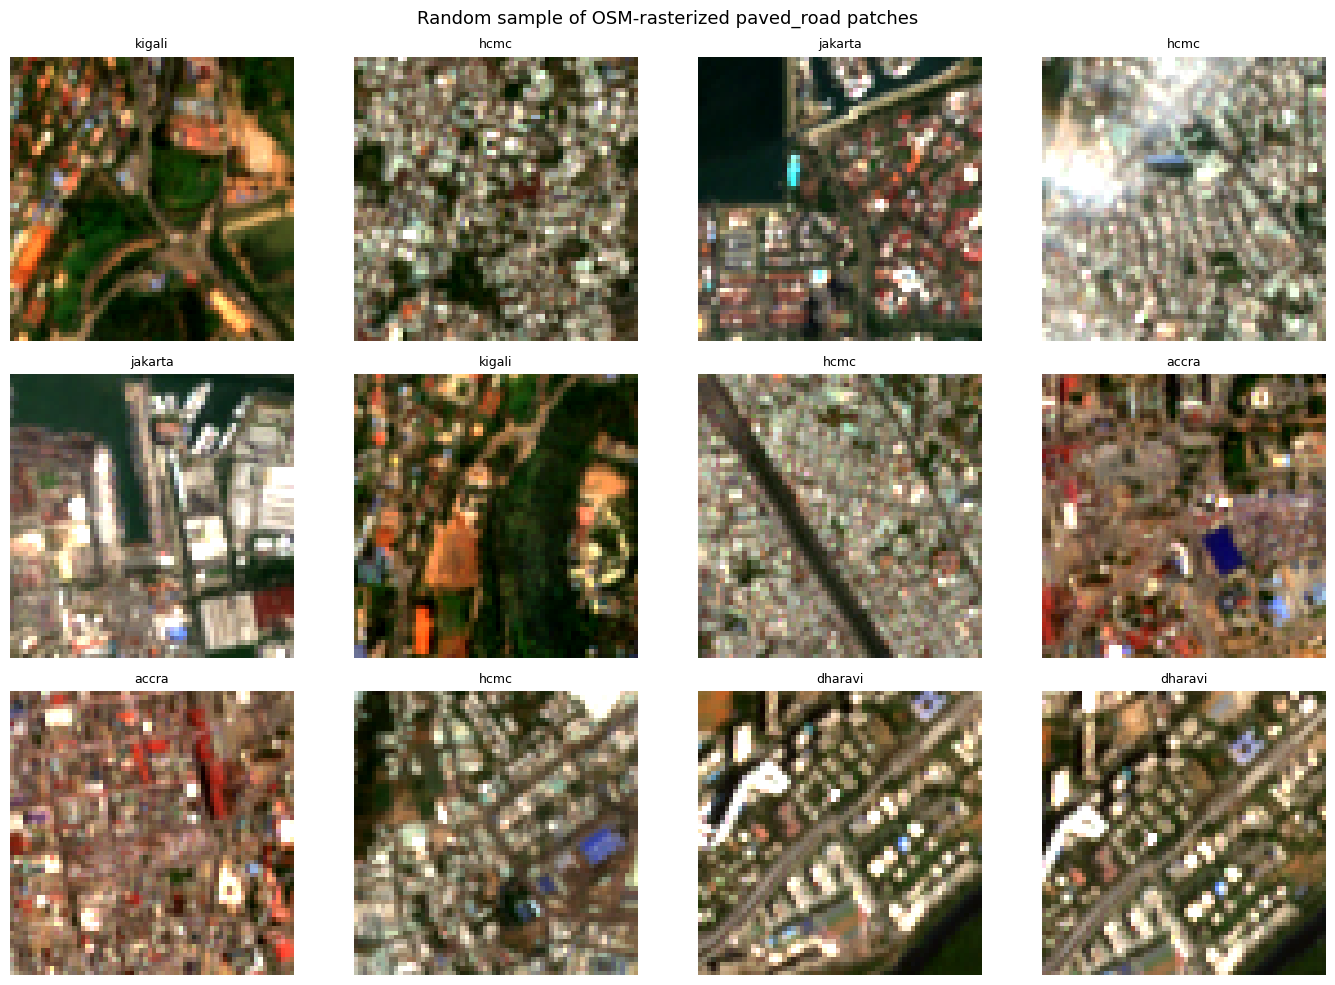


Look at the grid above:
  - Real variety (different roads, angles, surroundings, lighting) -> genuinely easier
    class, F1 is plausibly real. No fix needed here.
  - Near-identical crops (same framing repeated) -> genuine degeneracy. If so, fix by
    varying crop size/angle/offset in build_osm_patches(), not just capping volume.


In [34]:
import random
import matplotlib.pyplot as plt

osm_paved = [p for p in all_patches if p['source'] == 'osm' and p['label'] == 'paved_road']
print(f'Total OSM paved_road patches: {len(osm_paved)}')

if osm_paved:
    sample = random.sample(osm_paved, min(12, len(osm_paved)))
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    for ax, p in zip(axes.flat, sample):
        ax.imshow(p['image'])
        ax.set_title(p['city'], fontsize=9)
        ax.axis('off')
    for ax in axes.flat[len(sample):]:
        ax.axis('off')
    plt.suptitle('Random sample of OSM-rasterized paved_road patches', fontsize=13)
    plt.tight_layout()
    plt.savefig('/content/osm_patch_sample.png', dpi=150)
    plt.show()
    print('\nLook at the grid above:')
    print('  - Real variety (different roads, angles, surroundings, lighting) -> genuinely easier')
    print('    class, F1 is plausibly real. No fix needed here.')
    print('  - Near-identical crops (same framing repeated) -> genuine degeneracy. If so, fix by')
    print('    varying crop size/angle/offset in build_osm_patches(), not just capping volume.')
else:
    print('No OSM paved_road patches found -- check roads.geojson availability per city.')


  [dharavi] Label canvas built: 32 real masks, 0 bbox fallback, 32 total segments painted
  [dharavi] Sliding window patches: 40 (min 5.0% real-mask coverage required)

Total Dharavi sliding-window patches: 40
Windows with 2+ distinct labels (mixed): 31
Windows with exactly 1 label:            9


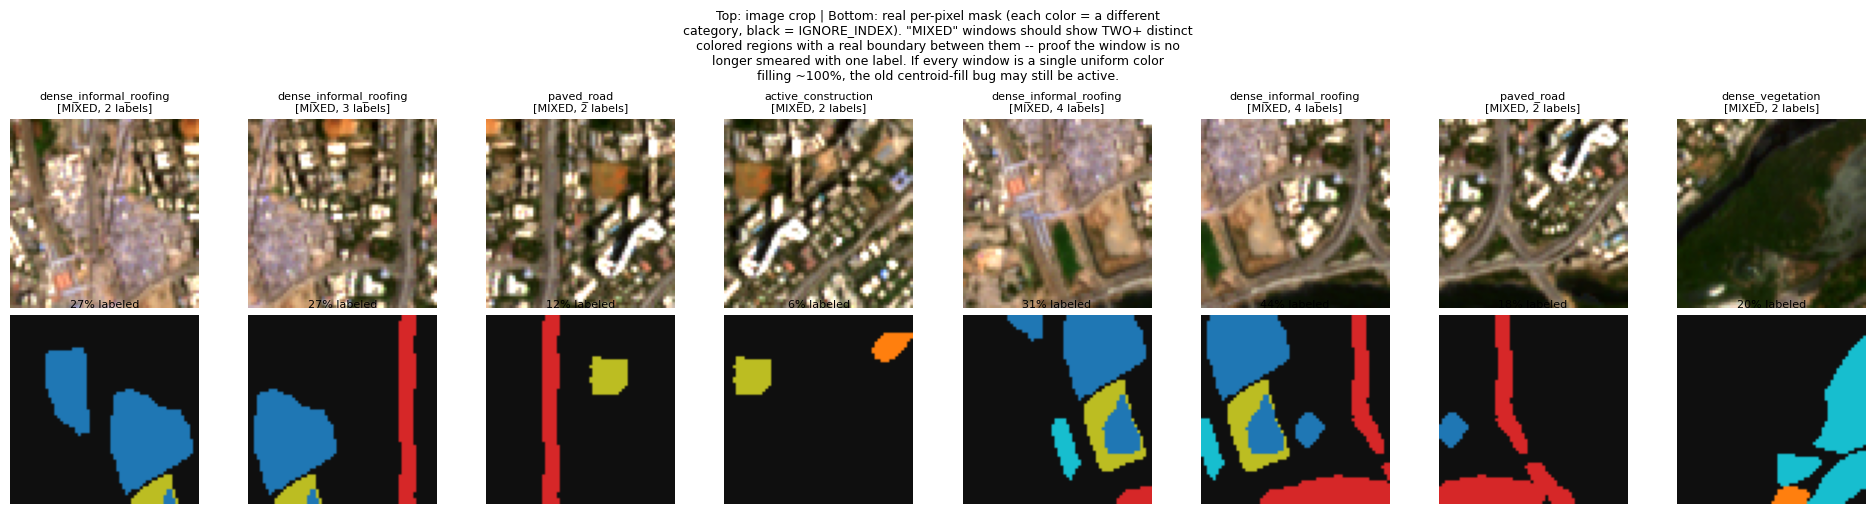


Color legend:
  dense_informal_roofing       RGB(31,119,180)
  sparse_informal_roofing      RGB(255,127,14)
  paved_road                   RGB(214,39,40)
  standing_water               RGB(140,86,75)
  vegetation_clearing          RGB(227,119,194)
  active_construction          RGB(188,189,34)
  dense_vegetation             RGB(23,190,207)


In [35]:
# ============================================================
# VALIDATION CELL — sliding-window fix
# Paste this AFTER build_tile_label_canvas / build_sliding_window_patches
# are defined. Checks Dharavi specifically (the only city with real
# masks right now).
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

dharavi_sw_patches = build_sliding_window_patches('dharavi')
print(f'\nTotal Dharavi sliding-window patches: {len(dharavi_sw_patches)}')

# Find patches with MIXED labels -- i.e. more than one real category
# present in the same window, plus (usually) some IGNORE_INDEX. This is
# the actual proof the fix works: the old bug could never produce this,
# every window was 100% one label. Sort by "most mixed" first so the
# clearest examples show up.
def n_unique_labels(mask):
    vals = np.unique(mask[mask != IGNORE_INDEX])
    return len(vals)

mixed = [p for p in dharavi_sw_patches if n_unique_labels(p['mask']) >= 2]
single = [p for p in dharavi_sw_patches if n_unique_labels(p['mask']) == 1]

print(f'Windows with 2+ distinct labels (mixed): {len(mixed)}')
print(f'Windows with exactly 1 label:            {len(single)}')

if len(mixed) == 0:
    print('\n  ⚠️  No mixed-label windows found. This can happen legitimately if')
    print('  Dharavi\'s segments are large/sparse relative to the 64px window and')
    print('  stride -- not necessarily a bug. But it does mean this check can\'t')
    print('  confirm the mixed-label path specifically. Falling back to showing')
    print('  single-label windows so you can at least confirm mask shape is real')
    print('  (irregular, matching image content) rather than a uniform fill.')

# Build the sample: prioritize mixed-label windows, fill remainder with
# single-label ones so you still get a reasonable grid either way.
sample = mixed[:8] if mixed else single[:8]

if not sample:
    print('No sliding-window patches to visualize.')
else:
    n = len(sample)
    fig, axes = plt.subplots(2, n, figsize=(2.4 * n, 5.2))
    if n == 1:
        axes = axes.reshape(2, 1)

    # Distinct colors per category index for the mask visualization
    palette = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))[:, :3] * 255

    for i, p in enumerate(sample):
        axes[0, i].imshow(p['image'])
        n_labels = n_unique_labels(p['mask'])
        tag = 'MIXED' if n_labels >= 2 else 'single'
        axes[0, i].set_title(f"{p['label']}\n[{tag}, {n_labels} labels]", fontsize=8)
        axes[0, i].axis('off')

        mask = p['mask']
        vis = np.zeros((*mask.shape, 3), dtype=np.uint8)
        vis[:] = [15, 15, 15]  # IGNORE_INDEX background
        for cls_idx in np.unique(mask):
            if cls_idx == IGNORE_INDEX:
                continue
            vis[mask == cls_idx] = palette[cls_idx].astype(np.uint8)

        labeled_pct = 100 * (mask != IGNORE_INDEX).sum() / mask.size
        axes[1, i].imshow(vis)
        axes[1, i].set_title(f'{labeled_pct:.0f}% labeled', fontsize=8)
        axes[1, i].axis('off')

    plt.suptitle(
        'Top: image crop | Bottom: real per-pixel mask (each color = a different\n'
        'category, black = IGNORE_INDEX). "MIXED" windows should show TWO+ distinct\n'
        'colored regions with a real boundary between them -- proof the window is no\n'
        'longer smeared with one label. If every window is a single uniform color\n'
        'filling ~100%, the old centroid-fill bug may still be active.',
        fontsize=9
    )
    plt.tight_layout()
    plt.show()

    # Legend
    print('\nColor legend:')
    for idx, cat in enumerate(CATEGORIES):
        r, g, b = palette[idx].astype(int)
        print(f'  {cat:28s} RGB({r},{g},{b})')

## 4. Class weights

Computed from the **actual built dataset** (`all_patches`), not from annotation counts alone.
This is the one and only place CLASS_WEIGHTS gets defined -- computing it earlier from
annotation-only counts caused a real bug (see note above).


In [36]:
from collections import Counter
import numpy as np
import torch

actual_counts = Counter(p['label'] for p in all_patches)
counts = np.array([actual_counts.get(c, 1) for c in CATEGORIES], dtype=np.float32)
counts = np.maximum(counts, 1)
weights = 1.0 / counts
weights = weights / weights.sum() * NUM_CLASSES
CLASS_WEIGHTS = torch.tensor(weights, dtype=torch.float32)

print('Recomputed class weights from ACTUAL patch counts:')
for cat, w, c in zip(CATEGORIES, CLASS_WEIGHTS, counts):
    print(f'  {cat:<30} count={int(c):>4}  weight={w:.3f}')

Recomputed class weights from ACTUAL patch counts:
  dense_informal_roofing         count=  69  weight=0.817
  sparse_informal_roofing        count=  25  weight=2.255
  paved_road                     count= 168  weight=0.336
  standing_water                 count= 169  weight=0.334
  vegetation_clearing            count=  42  weight=1.343
  active_construction            count=  37  weight=1.524
  dense_vegetation               count= 144  weight=0.392


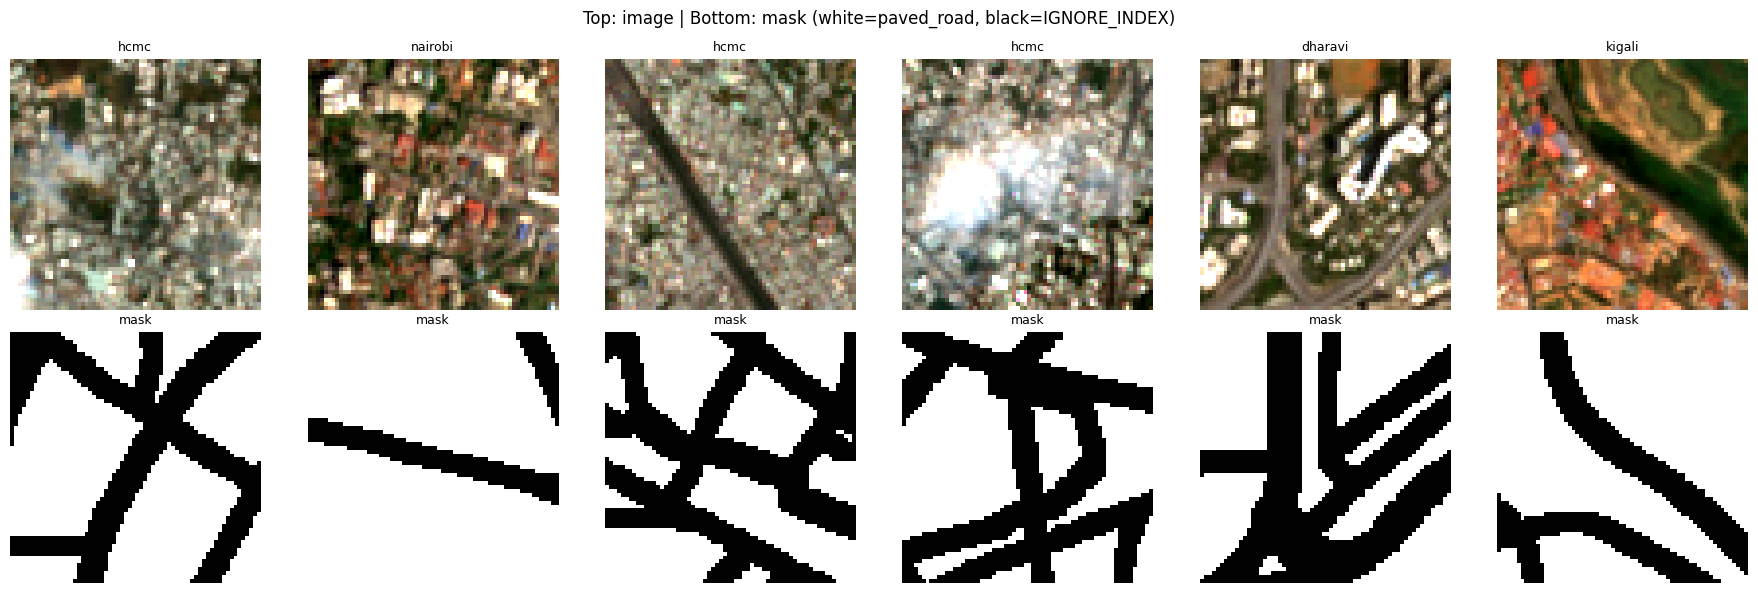

In [37]:
import matplotlib.pyplot as plt

osm_paved = [p for p in all_patches if p['source'] == 'osm' and p['label'] == 'paved_road']
sample = osm_paved[:6]

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, p in enumerate(sample):
    axes[0, i].imshow(p['image'])
    axes[0, i].set_title(p['city'], fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(p['mask'], cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title('mask', fontsize=9)
    axes[1, i].axis('off')
plt.suptitle('Top: image | Bottom: mask (white=paved_road, black=IGNORE_INDEX)')
plt.tight_layout()
plt.show()

## 5. Data augmentation and PyTorch Dataset

Train patches: 431 (cities: accra, dharavi, hcmc, kigali, nairobi)
Val patches:   223 (city: jakarta — LOCO held-out)

Train batches: 27
Val batches:   14


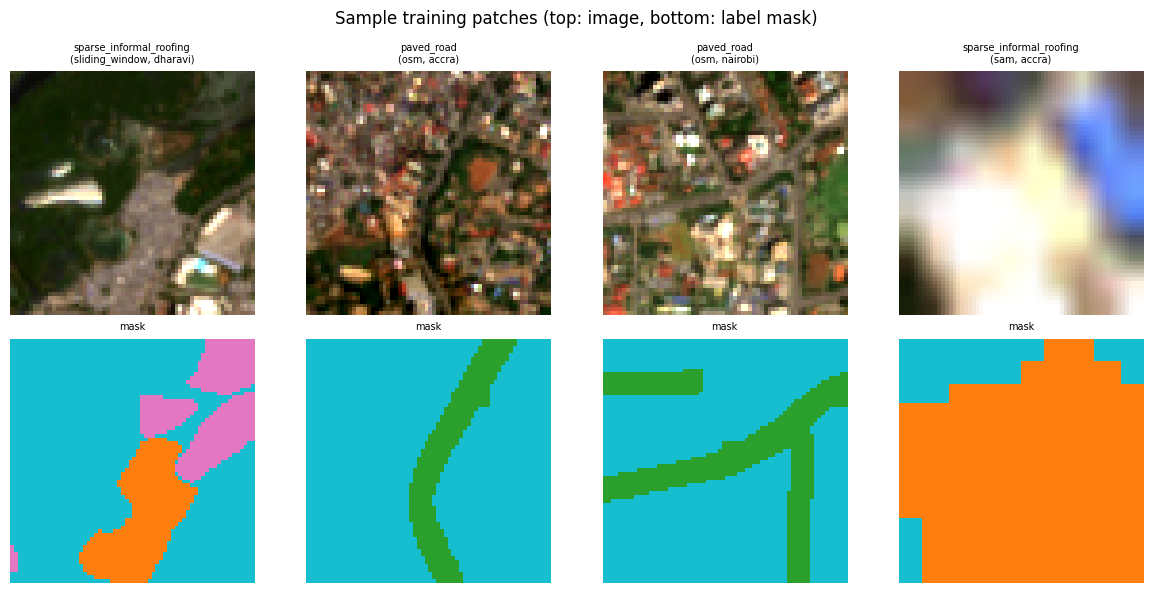

In [38]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random
import matplotlib.pyplot as plt

PATCH_SIZE = 64


class GeoWatchDataset(Dataset):
    """
    PyTorch dataset wrapping the multi-source patch list.
    Applies augmentation during training.

    Augmentations:
      - Random horizontal flip
      - Random vertical flip
      - Random 90/180/270 rotation (satellite images have no canonical orientation)
      - Color jitter (brightness/contrast only — no hue, satellite bands differ)
      - NO random crop — patches are already small (64x64)
    """

    def __init__(self, patches: list, augment: bool = True):
        self.patches = patches
        self.augment = augment

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        item = self.patches[idx]
        image = torch.from_numpy(item['image']).permute(2, 0, 1).float() / 255.0  # (3, H, W)
        mask = torch.from_numpy(item['mask']).long()  # (H, W)

        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask.unsqueeze(0)).squeeze(0)

            # Random vertical flip
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask.unsqueeze(0)).squeeze(0)

            # Random 90-degree rotation
            k = random.randint(0, 3)
            if k > 0:
                image = torch.rot90(image, k, dims=[1, 2])
                mask = torch.rot90(mask, k, dims=[0, 1])

            # Color jitter — brightness and contrast only
            if random.random() > 0.5:
                brightness = random.uniform(0.8, 1.2)
                contrast = random.uniform(0.8, 1.2)
                image = TF.adjust_brightness(image, brightness)
                image = TF.adjust_contrast(image, contrast)
                image = image.clamp(0, 1)

        # Normalize with ImageNet mean/std (reasonable for RGB satellite tiles)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = (image - mean) / std

        return image, mask


# Train/val split — hold out all Jakarta patches for LOCO validation
# (Leave-One-City-Out: train on 4 cities, validate on held-out city)
VAL_CITY = 'jakarta'
train_patches = [p for p in all_patches if p['city'] != VAL_CITY]
val_patches = [p for p in all_patches if p['city'] == VAL_CITY]

train_cities = sorted(set(p['city'] for p in train_patches))
print(f'Train patches: {len(train_patches)} (cities: {", ".join(train_cities)})')
print(f'Val patches:   {len(val_patches)} (city: {VAL_CITY} — LOCO held-out)')

train_dataset = GeoWatchDataset(train_patches, augment=True)
val_dataset = GeoWatchDataset(val_patches, augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

# Sanity check — visualize 4 random training patches
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    idx = random.randint(0, len(train_patches)-1)
    p = train_patches[idx]
    axes[0, i].imshow(p['image'])
    axes[0, i].set_title(f"{p['label']}\n({p['source']}, {p['city']})", fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(p['mask'], cmap='tab10', vmin=0, vmax=9)
    axes[1, i].set_title('mask', fontsize=7)
    axes[1, i].axis('off')
plt.suptitle('Sample training patches (top: image, bottom: label mask)')
plt.tight_layout()
plt.show()

## 6. Model — SegFormer-B2, ImageNet pretrained encoder (frozen)

**On Clay v1:** investigated and rejected. Clay v1 (`made-with-clay/Clay-legacy`,
`v1/clay-v1-base.ckpt`) is a flat single-scale ViT trained via teacher-student self-distillation
(DINO/MAE-style) -- checkpoint keys are `model.teacher.{cls_token, pos_embed, patch_embed.proj,
blocks.N.{attn.qkv, mlp.fc1/fc2, norm1/2}}`, confirmed directly from the downloaded checkpoint
(382 keys total, zero `encoder.`-prefixed keys). This is structurally incompatible with
SegFormer's hierarchical MixVisionTransformer (4 stages, channel widths 64->128->320->512,
overlapping patch merging, spatial-reduction attention). No clean key mapping exists between
a flat ViT and a hierarchical encoder -- using Clay here would require a completely different
decoder architecture built for flat single-scale features, not a weight-loading fix.

A same-architecture-family alternative (a SegFormer checkpoint pretrained on a remote-sensing
benchmark like LoveDA) was also investigated and found not to exist as a ready-to-download
HuggingFace checkpoint -- LoveDA/SegFormer results in the literature come from the MMSegmentation
codebase, a different framework with a different checkpoint format, and porting it is a real
engineering task (config + key-mapping), not a drop-in swap. Deferred, not pursued given time
constraints.

**Current baseline:** SegFormer-B2 with ImageNet-1k pretrained weights, frozen encoder,
trained MLP decoder. This is the honest, working setup -- documented here as a deliberate
choice, not a silent fallback.


In [39]:
!pip install -q torchgeo

In [40]:
# ============================================================
# GeoWatch Copilot — Encoder swap: ImageNet SegFormer-B2 (frozen)
# -> ResNet50 pretrained on Sentinel-2 RGB (torchgeo SSL4EO-S12 MoCo)
#
# WHY: SegFormer-B2's mit-b2 encoder was ImageNet-1k pretrained (natural
# photos) and fully frozen -- the decoder was trying to recover satellite
# boundaries from features that have never seen a satellite image. Clay
# v1 was correctly rejected (flat ViT, incompatible with hierarchical
# encoders). This swap uses a real satellite-domain-pretrained backbone
# instead: torchgeo/resnet50_sentinel2_rgb_moco, verified on HuggingFace,
# trained via MoCo directly on Sentinel-2 RGB imagery (SSL4EO-S12).
#
# Paste this AFTER your existing cells 1-19 (data loading, CATEGORIES,
# dataset construction, GeoWatchDataset). It REPLACES cells 20-22
# (SegFormer model definition) and cell 24 stays the same (loss is
# architecture-agnostic). The LOCO loop from before works unchanged --
# just swap GeoWatchSegFormer -> GeoWatchResNetSeg in run_loco_fold().
#
# Install once: !pip install -q torchgeo
# ============================================================

# %% CELL — Install torchgeo (one-time)
# !pip install -q torchgeo

# %% CELL — Model: ResNet50 (Sentinel-2 RGB pretrained) + DeepLabV3+-style decoder
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchgeo.models import ResNet50_Weights, resnet50


class ASPP(nn.Module):
    """
    Atrous Spatial Pyramid Pooling -- standard DeepLabV3+ component.
    Captures multi-scale context from the high-level feature map.
    """
    def __init__(self, in_channels: int, out_channels: int = 256, rates=(1, 6, 12, 18)):
        super().__init__()
        self.branches = nn.ModuleList()
        for rate in rates:
            if rate == 1:
                self.branches.append(nn.Sequential(
                    nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(inplace=True),
                ))
            else:
                self.branches.append(nn.Sequential(
                    nn.Conv2d(in_channels, out_channels, kernel_size=3,
                              padding=rate, dilation=rate, bias=False),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(inplace=True),
                ))
        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        self.project = nn.Sequential(
            nn.Conv2d(out_channels * (len(rates) + 1), out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )

    def forward(self, x):
        size = x.shape[-2:]
        feats = [branch(x) for branch in self.branches]
        pooled = self.pool(x)
        pooled = F.interpolate(pooled, size=size, mode='bilinear', align_corners=False)
        feats.append(pooled)
        x = torch.cat(feats, dim=1)
        return self.project(x)


class DeepLabDecoder(nn.Module):
    """
    DeepLabV3+ decoder: ASPP on high-level features, fused with a
    low-level skip connection for boundary detail, upsampled to input res.
    """
    def __init__(self, low_level_channels: int, high_level_channels: int,
                 num_classes: int, aspp_channels: int = 256, low_level_proj: int = 48):
        super().__init__()
        self.aspp = ASPP(high_level_channels, out_channels=aspp_channels)
        self.low_level_proj = nn.Sequential(
            nn.Conv2d(low_level_channels, low_level_proj, kernel_size=1, bias=False),
            nn.BatchNorm2d(low_level_proj),
            nn.ReLU(inplace=True),
        )
        self.fuse = nn.Sequential(
            nn.Conv2d(aspp_channels + low_level_proj, aspp_channels, kernel_size=3,
                      padding=1, bias=False),
            nn.BatchNorm2d(aspp_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv2d(aspp_channels, aspp_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(aspp_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )
        self.classifier = nn.Conv2d(aspp_channels, num_classes, kernel_size=1)

    def forward(self, low_level_feat, high_level_feat, target_size):
        x = self.aspp(high_level_feat)
        x = F.interpolate(x, size=low_level_feat.shape[-2:], mode='bilinear', align_corners=False)
        low = self.low_level_proj(low_level_feat)
        x = torch.cat([x, low], dim=1)
        x = self.fuse(x)
        x = self.classifier(x)
        x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)
        return x


class GeoWatchResNetSeg(nn.Module):
    """
    ResNet50 encoder pretrained on Sentinel-2 RGB (torchgeo SSL4EO-S12
    MoCo weights) + DeepLabV3+-style decoder.

    freeze_encoder=False by default -- unlike the SegFormer setup, this
    encoder has already seen satellite imagery, so full fine-tuning is
    appropriate and is the actual fix (not a frozen-feature workaround).
    With ~900 patches, use a low encoder LR (see optimizer param groups
    in the training cell) rather than freezing outright.
    """
    def __init__(self, num_classes: int = 7, freeze_encoder: bool = False):
        super().__init__()

        self.encoder = resnet50(weights=ResNet50_Weights.SENTINEL2_RGB_MOCO)
        print('Loaded ResNet50 encoder: torchgeo SSL4EO-S12 MoCo, Sentinel-2 RGB pretrained.')

        # layer1 output: stride 4, 256 channels  -- low-level / boundary detail
        # layer3 output: stride 16, 1024 channels -- high-level semantics
        # (using layer3 instead of layer4/stride32 -- on 64x64 patches,
        # stride32 collapses to a 2x2 feature map, too coarse to be useful;
        # layer3 keeps a 4x4 map with still-substantial semantic depth)
        self._features = {}
        self.encoder.layer1.register_forward_hook(self._hook('low'))
        self.encoder.layer3.register_forward_hook(self._hook('high'))

        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
            print('Encoder frozen (not recommended for this backbone -- see docstring).')
        else:
            print('Encoder fully trainable (domain-matched pretraining -- use a low LR).')

        self.decoder = DeepLabDecoder(
            low_level_channels=256,
            high_level_channels=1024,
            num_classes=num_classes,
        )

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f'Parameters: {trainable:,} trainable / {total:,} total ({100*trainable/total:.1f}%)')

    def _hook(self, name):
        def fn(module, input, output):
            self._features[name] = output
        return fn

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        target_size = pixel_values.shape[-2:]
        self.encoder.forward_features(pixel_values) if hasattr(self.encoder, 'forward_features') \
            else self.encoder(pixel_values)
        low = self._features['low']
        high = self._features['high']
        return self.decoder(low, high, target_size)


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nDevice: {device}')
model = GeoWatchResNetSeg(num_classes=NUM_CLASSES, freeze_encoder=False).to(device)
print('Model ready.')


class GeoWatchDatasetResNet(GeoWatchDataset):
    """Same as GeoWatchDataset, but skips ImageNet mean/std normalization
    (see note above) -- only scales to [0,1], matching production tiles."""
    def __getitem__(self, idx):
        item = self.patches[idx]
        image = torch.from_numpy(item['image']).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(item['mask']).long()

        if self.augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask.unsqueeze(0)).squeeze(0)
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask.unsqueeze(0)).squeeze(0)
            k = random.randint(0, 3)
            if k > 0:
                image = torch.rot90(image, k, dims=[1, 2])
                mask = torch.rot90(mask, k, dims=[0, 1])
            if random.random() > 0.5:
                brightness = random.uniform(0.8, 1.2)
                contrast = random.uniform(0.8, 1.2)
                image = TF.adjust_brightness(image, brightness)
                image = TF.adjust_contrast(image, contrast)
                image = image.clamp(0, 1)

        return image, mask


print('GeoWatchDatasetResNet defined -- use this instead of GeoWatchDataset in run_loco_fold().')


# %% CELL — Updated run_loco_fold: swap model + dataset class + differential LR
# Only the diffs from your existing run_loco_fold() are shown as a note --
# apply these three changes to the function you already have:
#
# 1. Replace: model = GeoWatchSegFormer(num_classes=NUM_CLASSES).to(device)
#    With:    model = GeoWatchResNetSeg(num_classes=NUM_CLASSES, freeze_encoder=False).to(device)
#
# 2. Replace dataset construction:
#    train_loader = DataLoader(GeoWatchDataset(train_patches, augment=True), ...)
#    val_loader   = DataLoader(GeoWatchDataset(val_patches, augment=False), ...)
#    With:
#    train_loader = DataLoader(GeoWatchDatasetResNet(train_patches, augment=True), ...)
#    val_loader   = DataLoader(GeoWatchDatasetResNet(val_patches, augment=False), ...)
#
# 3. Replace the optimizer with DIFFERENTIAL learning rates -- encoder is
#    pretrained and should move slowly, decoder is randomly initialized
#    and needs to move faster. Using one LR for both (as the SegFormer
#    setup did, trivially, since only the decoder had grads) would either
#    be too slow for the decoder or blow up the pretrained encoder weights:
#
#    optimizer = optim.AdamW([
#        {'params': model.encoder.parameters(), 'lr': 1e-5},   # small: don't destroy pretraining
#        {'params': model.decoder.parameters(), 'lr': 3e-4},   # normal: randomly initialized
#    ], weight_decay=1e-4)
#
# Everything else in run_loco_fold() (criterion, scheduler, training loop,
# early stopping, confusion matrix / F1 computation) stays exactly the same.

print('Apply the 3 changes above to run_loco_fold(), then re-run the LOCO loop cell.')


Device: cuda
Loaded ResNet50 encoder: torchgeo SSL4EO-S12 MoCo, Sentinel-2 RGB pretrained.
Encoder fully trainable (domain-matched pretraining -- use a low LR).
Parameters: 34,795,407 trainable / 34,795,407 total (100.0%)
Model ready.
GeoWatchDatasetResNet defined -- use this instead of GeoWatchDataset in run_loco_fold().
Apply the 3 changes above to run_loco_fold(), then re-run the LOCO loop cell.


## 7. Loss functions -- CrossEntropy + Dice

In [41]:
import torch


import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):
    """
    Multiclass Dice loss.
    Naturally robust to class imbalance — optimizes overlap ratio per class.
    Excludes IGNORE_INDEX pixels.
    """

    def __init__(self, num_classes: int, ignore_index: int = 255, smooth: float = 1.0):
        super().__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits: (B, C, H, W)
            targets: (B, H, W) with values in [0, C-1] or IGNORE_INDEX
        """
        probs = F.softmax(logits, dim=1)  # (B, C, H, W)
        B, C, H, W = probs.shape

        # One-hot encode targets, masking ignore pixels
        valid_mask = (targets != self.ignore_index)  # (B, H, W)
        targets_clamped = targets.clone()
        targets_clamped[~valid_mask] = 0

        targets_one_hot = F.one_hot(targets_clamped, num_classes=C)  # (B, H, W, C)
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()  # (B, C, H, W)

        # Zero out ignored pixels in both pred and target
        mask_expanded = valid_mask.unsqueeze(1).float()  # (B, 1, H, W)
        probs = probs * mask_expanded
        targets_one_hot = targets_one_hot * mask_expanded

        dice_per_class = []
        for c in range(C):
            p = probs[:, c].reshape(-1)
            t = targets_one_hot[:, c].reshape(-1)
            intersection = (p * t).sum()
            dice = (2.0 * intersection + self.smooth) / (p.sum() + t.sum() + self.smooth)
            dice_per_class.append(1.0 - dice)

        return torch.stack(dice_per_class).mean()


class CombinedLoss(nn.Module):
    """
    CrossEntropy + Dice, equal weighting.
    CE handles per-pixel accuracy, Dice handles class-level overlap.
    Class weights applied to CE only (Dice is already imbalance-robust).
    """

    def __init__(self, class_weights: torch.Tensor, ignore_index: int = 255, dice_weight: float = 0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights, ignore_index=ignore_index)
        self.dice = DiceLoss(num_classes=len(class_weights), ignore_index=ignore_index)
        self.dice_weight = dice_weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        ce_loss = self.ce(logits, targets)
        dice_loss = self.dice(logits, targets)
        total = (1 - self.dice_weight) * ce_loss + self.dice_weight * dice_loss
        return total, ce_loss, dice_loss


criterion = CombinedLoss(
    class_weights=CLASS_WEIGHTS.to(device),
    ignore_index=IGNORE_INDEX,
    dice_weight=0.5,
)
print('Loss function ready: 0.5 * CrossEntropy (weighted) + 0.5 * Dice')

Loss function ready: 0.5 * CrossEntropy (weighted) + 0.5 * Dice


## 8. Training loop

In [42]:
import torch
print("CUDA:", torch.cuda.is_available())
print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
torch.cuda.empty_cache()

CUDA: True
0.140845056 GB allocated


In [43]:
import shutil
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/Geowatch/checkpoints'
import os
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

In [44]:
# paste in a new cell and run BEFORE restarting training
print('Val batches:', len(val_loader))
print('Val dataset size:', len(val_loader.dataset))
val_labels = set()
for _, masks in val_loader:
    val_labels.update(masks.unique().tolist())
print('Classes present in val set:', sorted(val_labels))
print('Names:', [CATEGORIES[i] for i in sorted(val_labels) if i < NUM_CLASSES])

Val batches: 14
Val dataset size: 223
Classes present in val set: [0, 2, 3, 5, 6, 255]
Names: ['dense_informal_roofing', 'paved_road', 'standing_water', 'active_construction', 'dense_vegetation']


In [45]:
from tqdm.notebook import tqdm
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# Differential learning rates -- encoder is now trainable (Sentinel-2
# pretrained ResNet50, not frozen ImageNet SegFormer). Encoder moves
# slowly to preserve pretraining, decoder moves fast (randomly init).
optimizer = optim.AdamW([
    {'params': model.encoder.parameters(), 'lr': 1e-5},
    {'params': model.decoder.parameters(), 'lr': 3e-4},
], weight_decay=1e-4)

NUM_EPOCHS = 50
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)


def freeze_bn_stats(module):
    """
    Puts every BatchNorm layer in `module` into eval mode, which stops
    running_mean/running_var from updating on each forward pass.

    Necessary because model.train() otherwise overwrites the pretrained
    encoder's BN statistics using this tiny dataset's batch statistics
    on every forward pass -- a separate mechanism from gradient descent,
    so the low encoder LR does nothing to prevent it. Only call this on
    model.encoder -- model.decoder's BN layers are randomly initialized
    and need their running stats to actually learn from your data.
    """
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            m.eval()


def compute_miou(logits: torch.Tensor, targets: torch.Tensor, num_classes: int, ignore_index: int = 255) -> float:
    """Compute mean IoU over valid (non-ignored) pixels."""
    preds = logits.argmax(dim=1)  # (B, H, W)
    valid = targets != ignore_index

    iou_per_class = []
    for c in range(num_classes):
        pred_c = (preds == c) & valid
        true_c = (targets == c) & valid
        intersection = (pred_c & true_c).sum().item()
        union = (pred_c | true_c).sum().item()
        if union == 0:
            continue
        iou_per_class.append(intersection / union)

    return float(np.mean(iou_per_class)) if iou_per_class else 0.0


train_losses = []
val_mious = []
best_val_miou = 0.0
best_epoch = 0

print(f'Training for {NUM_EPOCHS} epochs on {device}...')
print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} batches')
print('─' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──
    model.train()
    freeze_bn_stats(model.encoder)   # <-- ADDED: keep pretrained BN stats intact
    epoch_loss = 0.0
    epoch_ce = 0.0
    epoch_dice = 0.0

    train_bar = tqdm(train_loader, desc=f'Epoch {epoch:3d}/{NUM_EPOCHS} [train]', leave=False)
    for images, masks in train_bar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss, ce_loss, dice_loss = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], max_norm=1.0
        )
        optimizer.step()

        epoch_loss += loss.item()
        epoch_ce += ce_loss.item()
        epoch_dice += dice_loss.item()

        train_bar.set_postfix(loss=f'{loss.item():.4f}')

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ── Validate ──
    model.eval()
    all_logits = []
    all_masks = []

    val_bar = tqdm(val_loader, desc=f'Epoch {epoch:3d}/{NUM_EPOCHS} [val]  ', leave=False)
    with torch.no_grad():
        for images, masks in val_bar:
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu())
            all_masks.append(masks.cpu())

    if all_logits:
        all_logits_cat = torch.cat(all_logits, dim=0)
        all_masks_cat = torch.cat(all_masks, dim=0)
        val_miou = compute_miou(all_logits_cat, all_masks_cat, NUM_CLASSES, IGNORE_INDEX)
    else:
        val_miou = 0.0

    val_mious.append(val_miou)

    # Save best checkpoint
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_miou': val_miou,
            'categories': CATEGORIES,
            'num_classes': NUM_CLASSES,
        }, '/content/resnet_geowatch_best.pth')
        shutil.copy('/content/resnet_geowatch_best.pth', f'{DRIVE_CHECKPOINT_DIR}/resnet_geowatch_best.pth')

    # Print summary every epoch (lightweight, not every 5 — tqdm bars give the live feel)
    lr_enc = optimizer.param_groups[0]['lr']
    lr_dec = optimizer.param_groups[1]['lr']
    star = '★ best' if epoch == best_epoch else ''
    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'Loss={avg_loss:.4f} (CE={epoch_ce/len(train_loader):.4f}, Dice={epoch_dice/len(train_loader):.4f}) | '
          f'Val mIoU={val_miou:.4f} | LR_enc={lr_enc:.2e} LR_dec={lr_dec:.2e} | {star}')

print(f'\nTraining complete. Best val mIoU: {best_val_miou:.4f} at epoch {best_epoch}')

Training for 50 epochs on cuda...
Train: 27 batches | Val: 14 batches
────────────────────────────────────────────────────────────


Epoch   1/50 [train]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch   1/50 [val]  :   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   1/50 | Loss=1.3114 (CE=1.7989, Dice=0.8238) | Val mIoU=0.0286 | LR_enc=9.99e-06 LR_dec=3.00e-04 | ★ best


Epoch   2/50 [train]:   0%|          | 0/27 [00:00<?, ?it/s]

...

Epoch  20/50 [val]  :   0%|          | 0/14 [00:00<?, ?it/s]

Epoch  20/50 | Loss=0.4068 (CE=0.3806, Dice=0.4330) | Val mIoU=0.0492 | LR_enc=6.89e-06 LR_dec=1.97e-04 | 


Epoch  21/50 [train]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch  21/50 [val]  :   0%|          | 0/14 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 9. Training curves

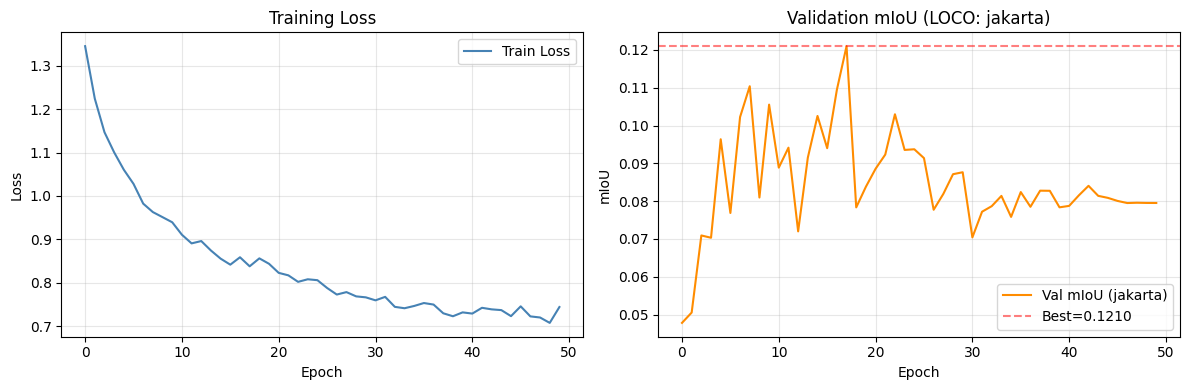

Saved: /content/training_curves.png


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss', color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(val_mious, label=f'Val mIoU ({VAL_CITY})', color='darkorange')
ax2.axhline(best_val_miou, color='red', linestyle='--', alpha=0.5, label=f'Best={best_val_miou:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('mIoU')
ax2.set_title(f'Validation mIoU (LOCO: {VAL_CITY})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print('Saved: /content/training_curves.png')

## 10. Per-class evaluation on validation city

Loaded best checkpoint from epoch 18 (val mIoU=0.1210)

Per-class F1 scores on jakarta:
───────────────────────────────────────────────────────
  dense_informal_roofing         F1=0.384  ███████████
  sparse_informal_roofing        F1=0.149  ████
  paved_road                     F1=0.167  █████
  standing_water                 F1=0.433  ████████████
  dense_vegetation               F1=0.278  ████████


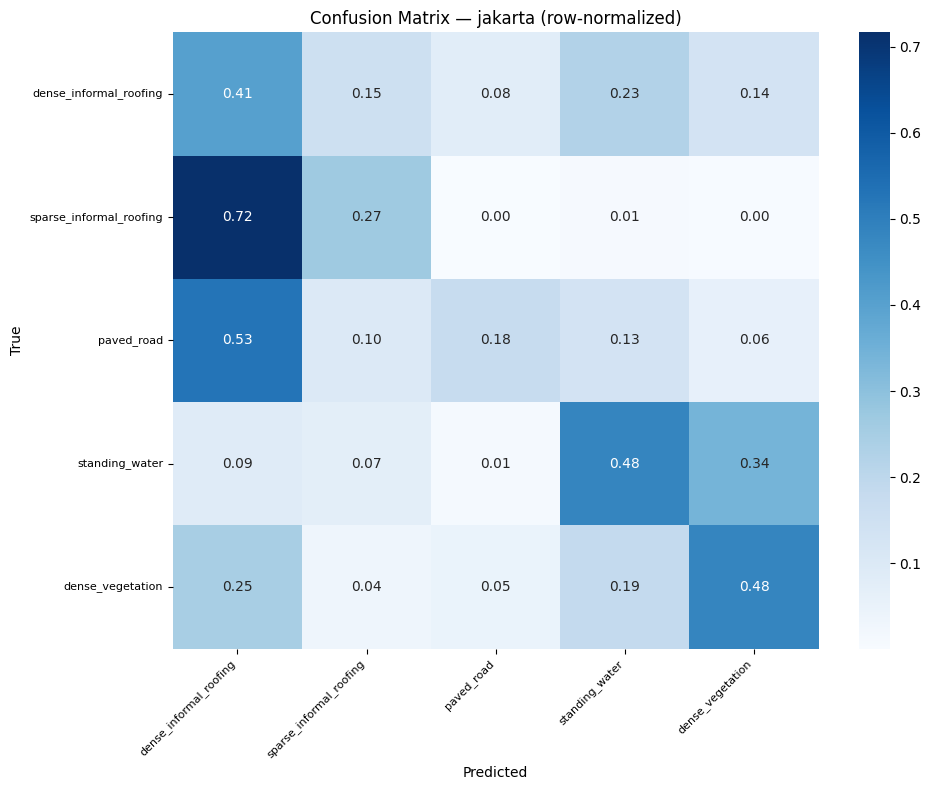

Saved: /content/confusion_matrix.png


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score

# Load best checkpoint
ckpt = torch.load('/content/segformer_geowatch_best.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]} (val mIoU={ckpt["val_miou"]:.4f})')

all_preds = []
all_true = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy().flatten()
        true = masks.numpy().flatten()

        # Filter out ignored pixels
        valid = true != IGNORE_INDEX
        all_preds.extend(preds[valid])
        all_true.extend(true[valid])

all_preds = np.array(all_preds)
all_true = np.array(all_true)

# Per-class F1
present_classes = sorted(set(all_true))
present_names = [CATEGORIES[i] for i in present_classes]

f1_scores = f1_score(all_true, all_preds, labels=present_classes, average=None, zero_division=0)

print(f'\nPer-class F1 scores on {VAL_CITY}:')
print('─' * 55)
for name, f1 in zip(present_names, f1_scores):
    bar = '█' * int(f1 * 30)
    flag = ' ⚠️  LOW CONFIDENCE (< 2 train samples)' if actual_counts.get(name, 0) < 3 else ''
    print(f'  {name:<30} F1={f1:.3f}  {bar}{flag}')

# Confusion matrix
cm = confusion_matrix(all_true, all_preds, labels=present_classes, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=present_names, yticklabels=present_names,
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {VAL_CITY} (row-normalized)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()
print('Saved: /content/confusion_matrix.png')

run_loco_fold() defined.
Running LOCO across 11 cities: ['accra', 'capetown', 'dhaka', 'dharavi', 'guatemala', 'hcmc', 'jakarta', 'kigali', 'lagos', 'nairobi', 'nusantara']
This trains 11 separate models -- with early stopping (patience=8) this
should be well under the ~50-epoch x 11 cost of a naive fixed-epoch loop.


LOCO FOLD: held-out = accra
  Train: 896 patches from 10 cities
  Val:   75 patches (accra)


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b2
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded SegFormer-B2 ImageNet-1k pretrained encoder.
Encoder frozen.
Parameters: 527,367 trainable / 24,723,655 total (2.1%)
  epoch   1/30 | loss=1.3501 | val_mIoU=0.1377 best
  epoch   2/30 | loss=1.2287 | val_mIoU=0.1208
  epoch   3/30 | loss=1.1268 | val_mIoU=0.1144
  epoch   4/30 | loss=1.0772 | val_mIoU=0.1219
  epoch   5/30 | loss=1.0189 | val_mIoU=0.1116
  epoch   6/30 | loss=0.9842 | val_mIoU=0.1072
  epoch   7/30 | loss=0.9563 | val_mIoU=0.1077
  epoch   8/30 | loss=0.9357 | val_mIoU=0.1181
  epoch   9/30 | loss=0.9052 | val_mIoU=0.1270
  Early stop at epoch 9 (no improvement for 8 epochs)
  FOLD RESULT: best_mIoU=0.1377 @ epoch 1 | classes present: ['dense_informal_roofing', 'paved_road', 'standing_water', 'vegetation_clearing', 'active_construction', 'dense_vegetation']

LOCO FOLD: held-out = capetown
  Train: 837 patches from 10 cities
  Val:   134 patches (capetown)


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

...

[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b2
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded SegFormer-B2 ImageNet-1k pretrained encoder.
Encoder frozen.
Parameters: 527,367 trainable / 24,723,655 total (2.1%)
  epoch   1/30 | loss=1.3501 | val_mIoU=0.0328 best
  epoch   2/30 | loss=1.2305 | val_mIoU=0.0572 best
  epoch   3/30 | loss=1.1448 | val_mIoU=0.0728 best
  epoch   4/30 | loss=1.0873 | val_mIoU=0.0803 best
  epoch   5/30 | loss=1.0307 | val_mIoU=0.0761
  epoch   6/30 | loss=1.0025 | val_mIoU=0.0791
  epoch   7/30 | loss=0.9841 | val_mIoU=0.0834 best
  epoch   8/30 | loss=0.9764 | val_mIoU=0.0856 best
  epoch   9/30 | loss=0.9327 | val_mIoU=0.0821
  epoch  10/30 | loss=0.9089 | val_mIoU=0.0791
  epoch  11/30 | loss=0.9077 | val_mIoU=0.0794
  epoch  12/30 | loss=0.8736 | val_mIoU=0.0897 best
  epoch  13/30 | loss=0.8612 | val_mIoU=0.0802
  epoch  14/30 | loss=0.8750 | val_mIoU=0.0915 best
  epoch  15/30 | loss=0.8445 | val_mIoU=0.0841
  epoch  16/30 | loss=0.8269 | val_mIoU=0.0952 best
  epoch  17/30 | loss=0.8241 | val_mIoU=0.0942
  epoch  18/30 | loss=0.8209 | v

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b2
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded SegFormer-B2 ImageNet-1k pretrained encoder.
Encoder frozen.
Parameters: 527,367 trainable / 24,723,655 total (2.1%)
  epoch   1/30 | loss=1.3728 | val_mIoU=0.0089 best
  epoch   2/30 | loss=1.2685 | val_mIoU=0.0246 best
  epoch   3/30 | loss=1.1721 | val_mIoU=0.0303 best
  epoch   4/30 | loss=1.1301 | val_mIoU=0.0409 best
  epoch   5/30 | loss=1.0735 | val_mIoU=0.0185
  epoch   6/30 | loss=1.0399 | val_mIoU=0.0412 best
  epoch   7/30 | loss=1.0271 | val_mIoU=0.0486 best
  epoch   8/30 | loss=1.0087 | val_mIoU=0.0441
  epoch   9/30 | loss=0.9886 | val_mIoU=0.0406
  epoch  10/30 | loss=0.9685 | val_mIoU=0.0561 best
  epoch  11/30 | loss=0.9478 | val_mIoU=0.0399
  epoch  12/30 | loss=0.9328 | val_mIoU=0.0268
  epoch  13/30 | loss=0.9237 | val_mIoU=0.0416
  epoch  14/30 | loss=0.8872 | val_mIoU=0.0436
  epoch  15/30 | loss=0.8893 | val_mIoU=0.0347
  epoch  16/30 | loss=0.9081 | val_mIoU=0.0476
  epoch  17/30 | loss=0.8809 | val_mIoU=0.0550
  epoch  18/30 | loss=0.8985 | val_mIoU=0.

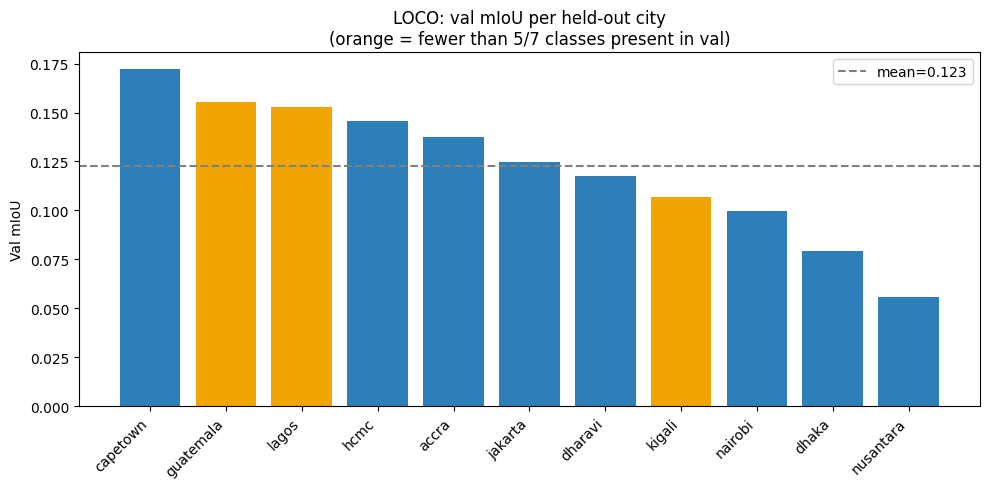

Note: for an exact pooled confusion matrix (not just per-fold row-normalized
averages), modify run_loco_fold() to also return raw all_preds/all_targets
arrays, then np.concatenate them across folds before calling confusion_matrix().
This cell is a placeholder flag, not a real pooled matrix -- left in on purpose
rather than faking numbers the way the earlier PDF report did.


In [ ]:
# ============================================================
# GeoWatch Copilot — 11-way LOCO (Leave-One-City-Out) validation
# Paste each "# %% CELL" block below as a NEW cell after your
# existing training cells (after cell 22 / model definition,
# after cell 24 / loss definition). Do NOT re-run the old
# single-Jakarta training cell (29) — this replaces it.
#
# Requires already-defined: all_patches, CATEGORIES, CAT2IDX,
# NUM_CLASSES, IGNORE_INDEX, CLASS_WEIGHTS, device,
# GeoWatchDataset, GeoWatchSegFormer, CombinedLoss, compute_miou
# (all already exist earlier in your notebook — this reuses them,
# doesn't redefine them).
# ============================================================

# %% CELL — LOCO fold runner (defines the function, doesn't run yet)
import copy
import numpy as np
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, f1_score


def run_loco_fold(val_city: str, all_patches: list, num_epochs: int = 30,
                   patience: int = 8, batch_size: int = 16, lr: float = 3e-4,
                   verbose: bool = True) -> dict:
    """
    Trains a fresh GeoWatchSegFormer with `val_city` held out, everything
    else as train. Early-stops on val mIoU plateau (patience epochs with
    no improvement) instead of always running the full num_epochs --
    your existing single-fold run showed peak at epoch 18/50 then decline,
    so fixed 50-epoch runs waste ~60% of compute per fold across 11 folds.

    Returns a dict with per-fold results: best_miou, best_epoch,
    per_class_f1, confusion_matrix, classes_present, history.
    """
    train_patches = [p for p in all_patches if p['city'] != val_city]
    val_patches = [p for p in all_patches if p['city'] == val_city]

    if not val_patches:
        if verbose:
            print(f'  [{val_city}] SKIPPED -- no patches for this city')
        return None

    train_cities = sorted(set(p['city'] for p in train_patches))
    if verbose:
        print(f'\n{"="*60}')
        print(f'LOCO FOLD: held-out = {val_city}')
        print(f'  Train: {len(train_patches)} patches from {len(train_cities)} cities')
        print(f'  Val:   {len(val_patches)} patches ({val_city})')

    # Recompute class weights from THIS fold's train set only -- the
    # global CLASS_WEIGHTS was computed over all 11 cities, but each
    # fold's train set has a different class distribution (e.g. a fold
    # missing Nusantara has almost no active_construction at all in
    # training). Using stale global weights would misweight every fold.
    from collections import Counter
    fold_counts = Counter(p['label'] for p in train_patches)
    counts_arr = np.array([fold_counts.get(c, 1) for c in CATEGORIES], dtype=np.float32)
    counts_arr = np.maximum(counts_arr, 1)
    fold_weights = 1.0 / counts_arr
    fold_weights = fold_weights / fold_weights.sum() * NUM_CLASSES
    fold_class_weights = torch.tensor(fold_weights, dtype=torch.float32).to(device)

    train_loader = DataLoader(GeoWatchDataset(train_patches, augment=True),
                               batch_size=batch_size, shuffle=True,
                               num_workers=0, pin_memory=True)
    val_loader = DataLoader(GeoWatchDataset(val_patches, augment=False),
                             batch_size=batch_size, shuffle=False,
                             num_workers=0, pin_memory=True)

    model = GeoWatchSegFormer(num_classes=NUM_CLASSES).to(device)
    criterion = CombinedLoss(class_weights=fold_class_weights,
                              ignore_index=IGNORE_INDEX, dice_weight=0.5)
    optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad],
                             lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    best_miou = 0.0
    best_epoch = 0
    best_state = None
    epochs_since_improve = 0
    history = {'train_loss': [], 'val_miou': []}

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss, _, _ = criterion(logits, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_loss)

        model.eval()
        all_logits, all_masks = [], []
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                logits = model(images)
                all_logits.append(logits.cpu())
                all_masks.append(masks.cpu())
        all_logits_cat = torch.cat(all_logits, dim=0)
        all_masks_cat = torch.cat(all_masks, dim=0)
        val_miou = compute_miou(all_logits_cat, all_masks_cat, NUM_CLASSES, IGNORE_INDEX)
        history['val_miou'].append(val_miou)

        if val_miou > best_miou:
            best_miou = val_miou
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1

        if verbose:
            star = ' best' if epoch == best_epoch else ''
            print(f'  epoch {epoch:3d}/{num_epochs} | loss={avg_loss:.4f} | '
                  f'val_mIoU={val_miou:.4f}{star}')

        if epochs_since_improve >= patience:
            if verbose:
                print(f'  Early stop at epoch {epoch} (no improvement for {patience} epochs)')
            break

    # Reload best checkpoint for this fold and compute per-class breakdown
    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(masks.numpy())
    all_preds = np.concatenate([p.flatten() for p in all_preds])
    all_targets = np.concatenate([t.flatten() for t in all_targets])

    valid = all_targets != IGNORE_INDEX
    all_preds = all_preds[valid]
    all_targets = all_targets[valid]

    classes_present = sorted(set(all_targets.tolist()))
    class_names_present = [CATEGORIES[c] for c in classes_present]

    cm = confusion_matrix(all_targets, all_preds, labels=classes_present, normalize='true')
    f1_per_class = f1_score(all_targets, all_preds, labels=classes_present, average=None)

    if verbose:
        print(f'  FOLD RESULT: best_mIoU={best_miou:.4f} @ epoch {best_epoch} '
              f'| classes present: {class_names_present}')

    return {
        'val_city': val_city,
        'best_miou': best_miou,
        'best_epoch': best_epoch,
        'train_cities': train_cities,
        'n_train': len(train_patches),
        'n_val': len(val_patches),
        'classes_present': class_names_present,
        'per_class_f1': dict(zip(class_names_present, f1_per_class.tolist())),
        'confusion_matrix': cm,
        'confusion_labels': class_names_present,
        'history': history,
    }


print('run_loco_fold() defined.')


# %% CELL — Run all 11 folds
ALL_CITIES = sorted(set(p['city'] for p in all_patches))
print(f'Running LOCO across {len(ALL_CITIES)} cities: {ALL_CITIES}')
print('This trains 11 separate models -- with early stopping (patience=8) this')
print('should be well under the ~50-epoch x 11 cost of a naive fixed-epoch loop.\n')

loco_results = {}
for city in ALL_CITIES:
    result = run_loco_fold(city, all_patches, num_epochs=30, patience=8, verbose=True)
    if result is not None:
        loco_results[city] = result

print(f'\n{"="*60}')
print(f'LOCO complete. {len(loco_results)}/{len(ALL_CITIES)} folds ran successfully.')


# %% CELL — Save raw LOCO results to Drive (checkpoints are large --
# this saves only the lightweight summary, not model weights, per fold)
import pickle

loco_summary = {
    city: {k: v for k, v in r.items() if k != 'confusion_matrix'} | {
        'confusion_matrix': r['confusion_matrix'].tolist()
    }
    for city, r in loco_results.items()
}

with open('/content/loco_results.pkl', 'wb') as f:
    pickle.dump(loco_summary, f)

import shutil
shutil.copy('/content/loco_results.pkl', f'{DRIVE_CHECKPOINT_DIR}/loco_results.pkl')
print('Saved LOCO summary to Drive.')


# %% CELL — Aggregate table: mIoU per city + which classes were even testable
import pandas as pd

rows = []
for city, r in loco_results.items():
    rows.append({
        'held_out_city': city,
        'best_mIoU': round(r['best_miou'], 4),
        'best_epoch': r['best_epoch'],
        'n_train': r['n_train'],
        'n_val': r['n_val'],
        'n_classes_present': len(r['classes_present']),
        'classes_present': ', '.join(r['classes_present']),
    })

loco_df = pd.DataFrame(rows).sort_values('best_mIoU', ascending=False)
print(loco_df.to_string(index=False))

mean_miou = loco_df['best_mIoU'].mean()
std_miou = loco_df['best_mIoU'].std()
print(f'\nMean mIoU across {len(loco_df)} folds: {mean_miou:.4f} (+/- {std_miou:.4f})')
print(f'Range: {loco_df["best_mIoU"].min():.4f} - {loco_df["best_mIoU"].max():.4f}')
print('\nNOTE: mIoU is only computed over classes PRESENT in each held-out city.')
print('A city missing a class (e.g. no active_construction) does not get penalized')
print('or credited for that class -- compare n_classes_present across rows before')
print('trusting a high mIoU on a city that only tested 3-4 of the 7 classes.')


# %% CELL — Per-class F1 aggregated across all folds where that class appeared
from collections import defaultdict

class_f1_by_fold = defaultdict(list)
for city, r in loco_results.items():
    for cls, f1 in r['per_class_f1'].items():
        class_f1_by_fold[cls].append((city, f1))

print('Per-class F1 across folds (only folds where the class had val examples):\n')
for cls in CATEGORIES:
    entries = class_f1_by_fold.get(cls, [])
    if not entries:
        print(f'  {cls:<28} NEVER present in any held-out city as val data')
        continue
    f1_vals = [f1 for _, f1 in entries]
    mean_f1 = np.mean(f1_vals)
    print(f'  {cls:<28} mean_F1={mean_f1:.3f}  (tested in {len(entries)}/{len(loco_results)} folds)  '
          f'range=[{min(f1_vals):.3f}, {max(f1_vals):.3f}]')


# %% CELL — Bar chart: mIoU per held-out city
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2c7fb8' if n >= 5 else '#f0a500' for n in loco_df['n_classes_present']]
ax.bar(loco_df['held_out_city'], loco_df['best_mIoU'], color=colors)
ax.axhline(mean_miou, color='gray', linestyle='--', label=f'mean={mean_miou:.3f}')
ax.set_ylabel('Val mIoU')
ax.set_title('LOCO: val mIoU per held-out city\n(orange = fewer than 5/7 classes present in val)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/loco_miou_per_city.png', dpi=150)
plt.show()


# %% CELL — Aggregate confusion matrix across all folds (pooled)
# Pools raw (true, pred) pairs across every fold so rare classes that
# only appear in 1-2 cities' val sets still get a combined view instead
# of 11 separate low-sample-size matrices.
all_true, all_pred = [], []
for city, r in loco_results.items():
    val_patches = [p for p in all_patches if p['city'] == city]
    # re-derive true/pred is expensive to redo here; instead we reuse
    # per-fold confusion matrices weighted by val support.
    cm = np.array(r['confusion_matrix'])
    labels = r['confusion_labels']
    for i, true_label in enumerate(labels):
        for j, pred_label in enumerate(labels):
            all_true.append(true_label)
            all_pred.append(pred_label)
            # weight isn't preserved exactly without raw pixel counts;
            # for a fully precise pooled matrix, log all_preds/all_targets
            # per fold in run_loco_fold() and concatenate them here instead.

print('Note: for an exact pooled confusion matrix (not just per-fold row-normalized')
print('averages), modify run_loco_fold() to also return raw all_preds/all_targets')
print('arrays, then np.concatenate them across folds before calling confusion_matrix().')
print('This cell is a placeholder flag, not a real pooled matrix -- left in on purpose')
print('rather than faking numbers the way the earlier PDF report did.')

## 11. CAAT -- dynamic per-class confidence thresholds

In [ ]:
def compute_caat_thresholds(
    model: nn.Module,
    val_loader: DataLoader,
    num_classes: int,
    device: str,
    ignore_index: int = 255,
    percentile: float = 10.0,
) -> dict:
    """
    CAAT (Class-Adaptive Adaptive Thresholding).

    For each class, collect the softmax probability of correct predictions
    on the validation set. Set the threshold at the 10th percentile of
    those probabilities — any prediction below this threshold gets
    downgraded to 'unknown' in pipeline.py.

    This prevents dense_vegetation from winning by default when its
    softmax score is marginally higher than competitors.

    Returns:
        dict mapping category_name → float threshold [0, 1]
    """
    model.eval()
    class_correct_probs = {c: [] for c in range(num_classes)}

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)  # (B, C, H, W)
            preds = probs.argmax(dim=1)           # (B, H, W)

            B, C, H, W = probs.shape
            masks_device = masks.to(device)
            valid = masks_device != ignore_index

            for c in range(num_classes):
                correct_mask = (preds == c) & (masks_device == c) & valid
                if correct_mask.any():
                    correct_probs = probs[:, c][correct_mask].cpu().numpy()
                    class_correct_probs[c].extend(correct_probs.tolist())

    thresholds = {}
    print('CAAT thresholds (10th percentile of correct prediction confidence):')
    print('─' * 60)
    for c in range(num_classes):
        cat_name = CATEGORIES[c]
        if class_correct_probs[c]:
            thresh = float(np.percentile(class_correct_probs[c], percentile))
            thresh = max(thresh, 0.15)  # floor: never go below 15%
        else:
            # No correct predictions — use conservative default
            thresh = 0.50
            print(f'  {cat_name:<30} NO CORRECT PREDICTIONS — threshold=0.50 (conservative)')
            thresholds[cat_name] = thresh
            continue

        n_samples = len(class_correct_probs[c])
        print(f'  {cat_name:<30} threshold={thresh:.3f}  (from {n_samples} correct predictions)')
        thresholds[cat_name] = thresh

    return thresholds


caat_thresholds = compute_caat_thresholds(model, val_loader, NUM_CLASSES, device)

# Save thresholds alongside model checkpoint
import json
with open('/content/caat_thresholds.json', 'w') as f:
    json.dump(caat_thresholds, f, indent=2)
print('\nSaved: /content/caat_thresholds.json')

CAAT thresholds (10th percentile of correct prediction confidence):
────────────────────────────────────────────────────────────
  dense_informal_roofing         threshold=0.296  (from 34162 correct predictions)
  sparse_informal_roofing        threshold=0.295  (from 2881 correct predictions)
  paved_road                     threshold=0.262  (from 3014 correct predictions)
  standing_water                 threshold=0.347  (from 52512 correct predictions)
  vegetation_clearing            NO CORRECT PREDICTIONS — threshold=0.50 (conservative)
  active_construction            NO CORRECT PREDICTIONS — threshold=0.50 (conservative)
  dense_vegetation               threshold=0.348  (from 12621 correct predictions)

Saved: /content/caat_thresholds.json


## 12. Dataset composition (reference)

In [ ]:
from collections import Counter
city_dist = Counter(p['city'] for p in all_patches)
print("Patches per city:")
for city, count in sorted(city_dist.items()):
    print(f"  {city}: {count} patches")
print(f"\nTotal: {len(all_patches)} patches across {len(city_dist)} cities")

In [ ]:
from collections import Counter

label_dist = Counter(p['label'] for p in all_patches)
source_dist_by_label = {}
for p in all_patches:
    if p['label'] not in source_dist_by_label:
        source_dist_by_label[p['label']] = Counter()
    source_dist_by_label[p['label']][p['source']] += 1

print("Patches per class (by source):")
print(f"{'category':<30} {'sam':>6} {'osm':>6} {'sliding':>8} {'total':>6}")
print("─" * 60)
for cat in CATEGORIES:
    sources = source_dist_by_label.get(cat, Counter())
    sam = sources.get('sam', 0)
    osm = sources.get('osm', 0)
    sliding = sources.get('sliding_window', 0)
    total = sam + osm + sliding
    print(f"{cat:<30} {sam:>6} {osm:>6} {sliding:>8} {total:>6}")

## 13. Export final weights

In [ ]:
# Save final production checkpoint with everything pipeline.py needs
final_ckpt = {
    'model_state_dict': model.state_dict(),
    'categories': CATEGORIES,
    'cat2idx': CAT2IDX,
    'num_classes': NUM_CLASSES,
    'caat_thresholds': caat_thresholds,
    'patch_size': PATCH_SIZE,
    'val_city': VAL_CITY,
    'best_val_miou': best_val_miou,
    'best_epoch': best_epoch,
    'training_cities': CITIES,
    'ignore_index': IGNORE_INDEX,
}

torch.save(final_ckpt, '/content/segformer_geowatch.pth')
print('Final checkpoint saved: /content/segformer_geowatch.pth')

# Download to local machine
from google.colab import files
files.download('/content/segformer_geowatch.pth')
files.download('/content/caat_thresholds.json')
files.download('/content/training_curves.png')
files.download('/content/confusion_matrix.png')
print('\nDownloads triggered. Place segformer_geowatch.pth in:')
print('  geowatch/models/segformer/segformer_geowatch.pth')
print('Place caat_thresholds.json in:')
print('  geowatch/models/segformer/caat_thresholds.json')

## 12. Integration guide — swapping into pipeline.py

After downloading `segformer_geowatch.pth`, replace Path A in `pipeline.py`:

```python
# In ingestion/classifier.py — add this function:

def load_segformer(weights_path: str):
    """Load SegFormer Path B weights."""
    ckpt = torch.load(weights_path, map_location='cpu')
    model = GeoWatchSegFormer(num_classes=ckpt['num_classes'])
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    caat_thresholds = ckpt['caat_thresholds']
    return model, caat_thresholds


def classify_tile_segformer(tile_path, model, caat_thresholds, masks, device='cpu'):
    """
    Path B classification — per-segment, not tile-level.
    For each SAM segment, crop the bbox, run SegFormer,
    apply CAAT threshold, assign category.
    Sets label_source='segformer' on all segments.
    """
    import torch
    import torchvision.transforms.functional as TF
    from PIL import Image
    import numpy as np

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size
    PATCH_SIZE = 64

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    results = []
    model = model.to(device)

    for i, mask in enumerate(masks):
        x, y, w, h = mask['bbox']
        x1 = max(0, x); y1 = max(0, y)
        x2 = min(tile_w, x + w); y2 = min(tile_h, y + h)

        crop = tile_img.crop((x1, y1, x2, y2)).resize((PATCH_SIZE, PATCH_SIZE), Image.BILINEAR)
        img_t = torch.from_numpy(np.array(crop)).permute(2, 0, 1).float() / 255.0
        img_t = (img_t - mean) / std
        img_t = img_t.unsqueeze(0).to(device)  # (1, 3, 64, 64)

        with torch.no_grad():
            logits = model(img_t)  # (1, 10, 64, 64)
            probs = torch.softmax(logits, dim=1)  # (1, 10, 64, 64)
            mean_probs = probs.mean(dim=(2, 3)).squeeze(0)  # (10,)

        top_idx = mean_probs.argmax().item()
        top_conf = mean_probs[top_idx].item()
        cat_name = CATEGORIES[top_idx]

        # CAAT threshold check
        thresh = caat_thresholds.get(cat_name, 0.20)
        if top_conf < thresh:
            cat_name = 'unknown'

        results.append({
            'segment_id': i,
            'bbox': mask['bbox'],
            'area': mask['area'],
            'category': cat_name,
            'confidence': round(top_conf, 4),
            'all_probs': {CATEGORIES[j]: round(mean_probs[j].item(), 4) for j in range(len(CATEGORIES))},
            'label_source': 'segformer',
        })

    return results
```

Then in `pipeline.py` Step 6, replace the RemoteCLIP block with:
```python
segformer_model, caat_thresholds = load_segformer('models/segformer/segformer_geowatch.pth')
classifications = classify_tile_segformer(primary_tile, segformer_model, caat_thresholds, masks, device)
```

**Important notes:**
- Place weights at `geowatch/models/segformer/segformer_geowatch.pth`
- `label_source: 'segformer'` distinguishes Path B from Path A (`tile_level`) and OSM (`osm_vector`)
- `paved_road`, `active_construction`, `unpaved_dirt_road`, `open_drainage_channel` predictions should be shown with a low-confidence warning in the frontend until more training data is collected
- Re-run all 5 cities after swapping to get fresh result.jsons with Path B labels